# pH-Dependent Free Energies of Protein Association from Protonation Ensemble Statistics
Stefan Hervø-Hansen<sup>a</sup> and Nobuyuki Matubayasi<sup>a</sup><br><br>
<sup>a</sup>Division of Chemical Engineering, Graduate School of Engineering Science, The University of Osaka, Toyonaka, Osaka 560-8531, Japan.<br>
*Correspondence:* stefan@cheng.es.osaka-u.ac.jp, nobuyuki@cheng.es.osaka-u.ac.jp

---


### Module Loading

In [1]:
import os
from multiprocessing import Pool
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import interp1d
import mdtraj as md
from scipy.interpolate import RegularGridInterpolator
from scipy import stats
from collections import Counter

mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'


## Function Definitions

In [2]:
# --------------------------------------------------
# Encode residue-specific protonation rules
# --------------------------------------------------

def _encode_residue_types(resnames):
    """
    Encode residue types as integers for fast protonation checks.

    Returns
    -------
    rtype : np.ndarray
        Integer codes per residue:
        0 = GLU/ASP/GL4   (protonated if state != 0)
        1 = LYS/TYR/CYS   (protonated if state != 1)
        2 = HIS           (protonated if state == 0)
    """

    rtype = np.empty(len(resnames), dtype=np.int8)

    for i, resname in enumerate(resnames):

        if resname in ["GLU", "ASP", "GL4"]:
            rtype[i] = 0

        elif resname in ["LYS", "TYR", "CYS"]:
            rtype[i] = 1

        elif resname == "HIS":
            rtype[i] = 2

        else:
            raise ValueError(f"Unknown residue type: {resname}")

    return rtype


# --------------------------------------------------
# Fast protonation classifier (clear semantics)
# --------------------------------------------------

def _is_protonated(rtype, state):
    """
    Determine if a residue is protonated.
    """

    return (
        (rtype == 0 and state != 0) or   # GLU/ASP/GL4
        (rtype == 1 and state != 1) or   # LYS/TYR/CYS
        (rtype == 2 and state == 0)      # HIS
    )


# --------------------------------------------------
# Worker (single pH)
# --------------------------------------------------

def _process_pH(args):
    base_path, pH, rtype, fraction, stride, min_frames = args

    filename = f"{base_path}/reordered_cpouts.pH_{pH:.2f}"

    if not os.path.isfile(filename):
        return pH, None

    n_res = len(rtype)
    N_frames = []

    with open(filename, "r") as f:

        residue_counter = 0
        current_N = 0

        for line in f:

            if line.startswith("Residue"):

                parts = line.split()
                res_index = int(parts[1])
                state = int(parts[-1])

                if _is_protonated(rtype[res_index], state):
                    current_N += 1

                residue_counter += 1

                if residue_counter == n_res:
                    N_frames.append(current_N)
                    current_N = 0
                    residue_counter = 0

    # Convert to NumPy
    N = np.array(N_frames, dtype=np.int16)

    # ------------------------------
    # Trimming + thinning
    # ------------------------------
    n_total = len(N)

    if n_total == 0:
        return pH, {"N": N, "n_frames": 0}

    if fraction < 1.0:
        start = int((1 - fraction) * n_total)

        if n_total - start < min_frames:
            start = max(0, n_total - min_frames)
    else:
        start = 0

    N = N[start::stride]

    return pH, {
        "N": N,
        "n_frames": len(N)
    }


# --------------------------------------------------
# Main function (clean + expressive)
# --------------------------------------------------

def load_protonation_counts(
    base_path,
    pHs,
    resnames,
    nprocs=None,
    fraction=1.0,
    stride=1,
    min_frames=1,
    verbose=False
):
    """
    Load protonation counts N for each pH.

    Includes:
    - parallel file loading
    - residue-aware protonation logic
    - optional equilibration trimming
    - optional subsampling

    Returns
    -------
    data : dict
        {pH: {"N": array, "n_frames": int}}
    """

    if nprocs is None:
        nprocs = min(len(pHs), os.cpu_count())

    nprocs = max(1, nprocs)

    # Precompute residue encoding once
    rtype = _encode_residue_types(resnames)

    args = [
        (base_path, pH, rtype, fraction, stride, min_frames)
        for pH in pHs
    ]

    data = {}

    with Pool(processes=nprocs) as pool:
        results = pool.map(_process_pH, args)

    for pH, result in results:

        if verbose and result is None:
            print(f"Missing: pH {pH:.2f}")
            continue

        data[pH] = result
        if verbose:
            print(f"Loaded pH {pH:.2f}: {result['n_frames']} frames")

    return data

# ----------------------
# Subsampling utilities 
# ----------------------
def subsample_data(N_frames, stride):
    return np.asarray(N_frames)[::stride]


def compute_effective_sample_size(N_frames, stride):
    return len(subsample_data(N_frames, stride))


# -----------------------------
# Observables WITH subsampling 
# -----------------------------
def extract_observables(data, pHs, stride=20):

    N_avg = []
    var_N = []
    M_eff = []

    for pH in pHs:

        if pH not in data:
            raise ValueError(f"Missing pH {pH}")

        N = data[pH]["N"]

        # Mean (full data)
        N_avg.append(np.mean(N))

        # Variance (full data, best estimate)
        var_N.append(np.var(N, ddof=1))

        # Effective sample size
        M_eff.append(compute_effective_sample_size(N, stride))

    return (
        np.array(N_avg),
        np.array(var_N),
        np.array(M_eff),
    )


# -----------------------------
# Reference model
# -----------------------------
def protonation_probability(pH, pKa):
    """⟨n⟩ for a single site"""
    return 1.0 / (1.0 + 10**(pH - pKa))


def compute_N_avg_reference(pHs, pKas):
    """⟨N⟩ for non-interacting reference system"""
    pHs = np.asarray(pHs)
    pKas = np.asarray(pKas)

    probs = protonation_probability(pHs[:, None], pKas[None, :])
    return probs.sum(axis=1)

    
def compute_var_reference(pHs, pKas):
    """
    Analytical Var(N) for independent sites
    Var(N) = sum_i p_i (1 - p_i)
    """
    pHs = np.asarray(pHs)
    pKas = np.asarray(pKas)

    probs = protonation_probability(pHs[:, None], pKas[None, :])
    return np.sum(probs * (1.0 - probs), axis=1)


# -----------------------------
# Thermodynamic Integration
# -----------------------------
def compute_Upsilon_TI_profile(
    pHs,
    N_avg,
    var_N=None,
    M_eff=None,
    pH_ref=7.0,
    include_discretization=True,
):
    """
    Compute cumulative TI free-energy profile and
    propagated uncertainties at each pH.

    Parameters
    ----------
    pHs : array-like
        pH grid

    N_avg : array-like
        <N> at each pH

    var_N : array-like, optional
        Variance of N at each pH

    M_eff : array-like, optional
        Effective number of independent samples

    pH_ref : float
        Reference pH for zero shifting

    include_discretization : bool
        Include discretization uncertainty profile

    Returns
    -------
    results : dict
        {
            "Upsilon": cumulative TI profile,
            "sigma_stat": statistical SE profile,
            "sigma_disc": discretization SE profile,
            "sigma_total": total SE profile
        }
    """

    kBT = 2.479
    ln10 = np.log(10)

    pHs = np.asarray(pHs, dtype=float)
    N_avg = np.asarray(N_avg, dtype=float)

    n = len(pHs)

    # -----------------------------------------
    # Cumulative TI integral
    # -----------------------------------------

    Upsilon = np.zeros(n)

    for i in range(1, n):

        dph = pHs[i] - pHs[i - 1]

        trap = 0.5 * (N_avg[i] + N_avg[i - 1])

        Upsilon[i] = (
            Upsilon[i - 1]
            + kBT * ln10 * trap * dph
        )

    # -----------------------------------------
    # Shift reference
    # -----------------------------------------

    idx_ref = np.argmin(np.abs(pHs - pH_ref))

    Upsilon -= Upsilon[idx_ref]

    # -----------------------------------------
    # If no error inputs supplied
    # -----------------------------------------

    if var_N is None or M_eff is None:

        return {
            "Upsilon": Upsilon
        }

    var_N = np.asarray(var_N, dtype=float)
    M_eff = np.asarray(M_eff, dtype=float)

    prefactor = kBT * ln10

    sigma_stat = np.zeros(n)
    sigma_disc = np.zeros(n)

    # -----------------------------------------
    # Statistical uncertainty profile
    # Eq. (1.10)
    # -----------------------------------------

    for i in range(1, n):

        dph_local = np.diff(pHs[:i+1])

        # trapezoidal weights for partial integral
        weights = np.ones(i + 1)

        weights[0] = 0.5
        weights[-1] = 0.5

        # include local spacing
        # generalized for nonuniform spacing
        weighted_var = np.sum(
            (weights * prefactor)**2
            * var_N[:i+1]
            * np.concatenate([
                [dph_local[0]],
                0.5 * (dph_local[:-1] + dph_local[1:])
                if len(dph_local) > 1 else [],
                [dph_local[-1]]
            ])**2
            / M_eff[:i+1]
        )

        sigma_stat[i] = np.sqrt(weighted_var)

    # -----------------------------------------
    # Discretization uncertainty profile
    # Eq. (1.12)
    # -----------------------------------------

    if include_discretization:

        for i in range(1, n):

            dph = np.mean(np.diff(pHs[:i+1]))

            disc = (
                kBT
                * (ln10 * dph)**2
                / 12.0
                * (var_N[i] - var_N[0])
            )

            sigma_disc[i] = abs(disc)

    # -----------------------------------------
    # Total uncertainty
    # -----------------------------------------

    sigma_total = np.sqrt(
        sigma_stat**2 +
        sigma_disc**2
    )

    return {
        "Upsilon": Upsilon,
        "sigma_stat": sigma_stat,
        "sigma_disc": sigma_disc,
        "sigma_total": sigma_total,
    }


def compute_deltaG_sigma(sig_Gn, sig_G1, n):
    """
    Error propagation for:
    ΔG = G(n)/n - G(1)
    """
    return np.sqrt(
        (sig_Gn / n)**2 +
        sig_G1**2
    )


## Insulin residue metadata (canonical labeling)

This cell constructs a canonical residue mapping directly from the simulation topology (`insulin_fibril_leap_output.pdb`) to ensure consistent and reproducible residue identification across all systems.

Rather than relying on hard-coded indices, residues are defined using biologically meaningful descriptors:

- chain identity
- residue sequence number (resSeq)
- residue name

From this mapping, we construct:

- residue_table: complete list of residues in the system
- titratable_residues: subset of residues included in CpHMD analysis
- titratable_indices: topology indices in the exact order used in simulation outputs

To enable direct comparison with canonical insulin, residues are aligned to the mature human insulin sequences (A and B chains). This allows automatic detection of truncations and assignment of canonical residue indices.

These objects define a consistent reference layer for all subsequent analysis and ensure that residue identities remain comparable across monomeric and protofibril systems, even when constructs differ.

In [3]:
# ============================================================
# Canonical mature human insulin
# ============================================================

INSULIN_B = "FVNQHLCGSHLVEALYLVCGERGFFYTPKT"
INSULIN_A = "GIVEQCCTSICSLYQLENYCN"

CANONICAL = {"A": INSULIN_A, "B": INSULIN_B}

CAP_RESNAMES = {"ACE","NME","NH2","CT3"}

AA3_TO_AA1 = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLU":"E","GL4":"E",
    "GLN":"Q","GLY":"G","HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M",
    "PHE":"F","PRO":"P","SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V"
}

TITRATABLE = {"GL4","HIS","LYS","TYR"}

# ============================================================
# Load topology
# ============================================================

topology = md.load("/data9/stefan/CpHMD/fibril_1/0_preparation/insulin_fibril_leap_output.pdb")
topology.remove_solvent(inplace=True)
top = topology.topology

# ============================================================
# Build residue table
# ============================================================

residue_table = []

for res in top.residues:
    residue_table.append({
        "top_index": res.index,
        "chain": res.chain.index,
        "resSeq": res.resSeq,
        "resname": res.name,
        "oneletter": AA3_TO_AA1.get(res.name,"X"),
        "is_cap": res.name in CAP_RESNAMES
    })

# ============================================================
# Assign biological chains (A/B)
# ============================================================

chains = sorted(set(r["chain"] for r in residue_table))

chain_lengths = {
    c: sum(1 for r in residue_table if r["chain"]==c and not r["is_cap"])
    for c in chains
}

sorted_chains = sorted(chain_lengths.items(), key=lambda x:x[1])

chain_map = {
    sorted_chains[0][0]:"A",
    sorted_chains[1][0]:"B"
}

for r in residue_table:
    r["bio_chain"] = chain_map[r["chain"]]

# ============================================================
# Extract fibril sequences
# ============================================================

fibril_seq = {}

for chain in ["A","B"]:
    seq = "".join(
        r["oneletter"]
        for r in sorted(
            [x for x in residue_table if x["bio_chain"]==chain and not x["is_cap"]],
            key=lambda x:x["resSeq"]
        )
    )
    fibril_seq[chain] = seq

# ============================================================
# Detect truncations + assign canonical indices
# ============================================================

offsets = {}

print("\n===== Fibril truncation report =====\n")

for chain in ["B","A"]:

    canon = CANONICAL[chain]
    fib = fibril_seq[chain]

    start = canon.find(fib)
    if start == -1:
        raise RuntimeError(f"Could not align chain {chain}")

    offsets[chain] = start

    print(f"Chain {chain}")
    print("Detected fibril:", fib)
    print("N-cut:", canon[:start])
    print("C-cut:", canon[start+len(fib):])
    print()

    chain_res = [
        r for r in residue_table
        if r["bio_chain"]==chain and not r["is_cap"]
    ]

    chain_res.sort(key=lambda x:x["resSeq"])

    for i, r in enumerate(chain_res):
        r["canonical_index"] = i + 1 + start

# ============================================================
# Analysis-ready objects
# ============================================================

titratable_residues = [
    r for r in residue_table
    if r["resname"] in TITRATABLE and not r["is_cap"]
]

titratable_indices = [r["top_index"] for r in titratable_residues]



===== Fibril truncation report =====

Chain B
Detected fibril: HLCGSHLVEALYLVCGERGFFYT
N-cut: FVNQ
C-cut: PKT

Chain A
Detected fibril: QCCTSICSLYQLENYC
N-cut: GIVE
C-cut: N



## Loading data

In [4]:
pHs = np.array([
    0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
    5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5,
    10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5
])

# Monomer
resnames_1mer = [r["resname"] for r in titratable_residues]
data_1mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_1/5_analysis",
    pHs=pHs,
    resnames=resnames_1mer
)

# Dimer
resnames_2mer = resnames_1mer * 2
data_2mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_2/5_analysis",
    pHs=pHs,
    resnames=resnames_2mer
)

# Trimer
resnames_3mer = resnames_1mer * 3
data_3mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_3/5_analysis",
    pHs=pHs,
    resnames=resnames_3mer
)

# Tetramer
resnames_4mer = resnames_1mer * 4
data_4mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_4/5_analysis",
    pHs=pHs,
    resnames=resnames_4mer
)

# Pentamer
resnames_5mer = resnames_1mer * 5
data_5mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_5/5_analysis",
    pHs=pHs,
    resnames=resnames_5mer
)

# Hexamer
resnames_6mer = resnames_1mer * 6
data_6mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_6/5_analysis",
    pHs=pHs,
    resnames=resnames_6mer
)

# Heptamer
resnames_7mer = resnames_1mer * 7
data_7mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_7/5_analysis",
    pHs=pHs,
    resnames=resnames_7mer
)

# Octamer
resnames_8mer = resnames_1mer * 8
data_8mer = load_protonation_counts(
    base_path="/data9/stefan/CpHMD/fibril_8/5_analysis",
    pHs=pHs,
    resnames=resnames_8mer
)


## From Macroscopic Titration Behavior to pH-Dependent Free Energies
### Extracting observables and subsampling

In [5]:
N_1mer, var_1mer, M_1mer = extract_observables(data_1mer, pHs)
N_2mer, var_2mer, M_2mer = extract_observables(data_2mer, pHs)
N_3mer, var_3mer, M_3mer = extract_observables(data_3mer, pHs)
N_4mer, var_4mer, M_4mer = extract_observables(data_4mer, pHs)
N_5mer, var_5mer, M_5mer = extract_observables(data_5mer, pHs)
N_6mer, var_6mer, M_6mer = extract_observables(data_6mer, pHs)
N_7mer, var_7mer, M_7mer = extract_observables(data_7mer, pHs)
N_8mer, var_8mer, M_8mer = extract_observables(data_8mer, pHs)


### Error analysis and reported values

Each figure is followed by a short cell that reports its uncertainty and any quoted numbers, so every value in the manuscript is reproduced here.

**All uncertainties are 95% confidence intervals.** Directly-sampled observables ($\langle N\rangle$, $\mathrm{Var}(N)$, $\Delta\nu$) use 20-block averaging (Student-$t$, 19 dof). The analytically-propagated free energies ($\Delta\Upsilon$, $\Delta\Delta\Upsilon$) use the combined statistical + discretization uncertainty of SI Section S1 scaled by $z=1.96$.

In [6]:
# ---- Error-analysis helpers (95% CIs via block averaging + landmark finders) ----
Z95 = stats.norm.ppf(0.975)                     # 1.959964  (z for 95% CI; analytical free energies)

def block_ci_mean(x, n_blocks=20, conf=0.95):
    """95% CI half-width of <x> from n_blocks contiguous blocks (Student-t)."""
    m = np.array([b.mean() for b in np.array_split(np.asarray(x, float), n_blocks)])
    return stats.t.ppf(0.5 + conf / 2.0, n_blocks - 1) * m.std(ddof=1) / np.sqrt(n_blocks)

def block_ci_var(x, n_blocks=20, conf=0.95):
    """95% CI half-width of Var(x) from n_blocks contiguous blocks (Student-t)."""
    v = np.array([b.var(ddof=1) for b in np.array_split(np.asarray(x, float), n_blocks)])
    return stats.t.ppf(0.5 + conf / 2.0, n_blocks - 1) * v.std(ddof=1) / np.sqrt(n_blocks)

def largest(ci_by_n, pHs):
    """(value, n, pH) of the largest CI over all fibril sizes and pH."""
    best = (-np.inf, None, None)
    for n, ci in ci_by_n.items():
        i = int(np.nanargmax(ci))
        if ci[i] > best[0]:
            best = (ci[i], n, pHs[i])
    return best

def interp_sign_change(pHs, y, lo, hi):
    """Interpolated pH values where y changes sign within [lo, hi]."""
    pHs = np.asarray(pHs, float); y = np.asarray(y, float); out = []
    for i in range(len(pHs) - 1):
        if lo <= pHs[i] <= hi and y[i] * y[i + 1] < 0:
            out.append(pHs[i] - y[i] * (pHs[i + 1] - pHs[i]) / (y[i + 1] - y[i]))
    return out

# observables keyed by fibril size n
data_by_n = {1: data_1mer, 2: data_2mer, 3: data_3mer, 4: data_4mer,
             5: data_5mer, 6: data_6mer, 7: data_7mer, 8: data_8mer}
N_by_n    = {1: N_1mer, 2: N_2mer, 3: N_3mer, 4: N_4mer,
             5: N_5mer, 6: N_6mer, 7: N_7mer, 8: N_8mer}

### Figure 1: ⟨N⟩ vs. pH

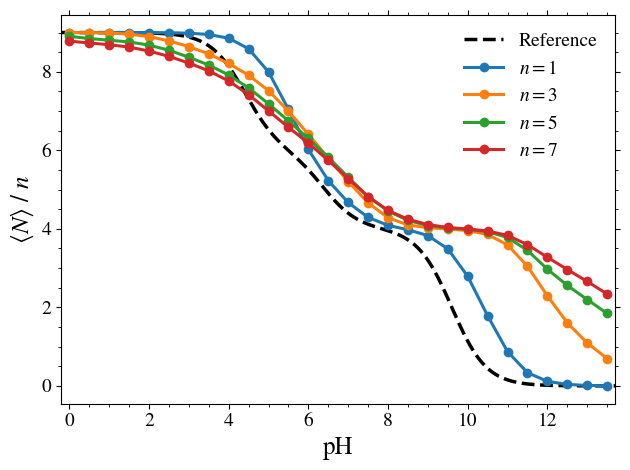

In [7]:
pKas_ref_1mer = (
    [6.4]*2 +   # His
    [4.4]*3 +   # Glu
    [9.6]*4     # Tyr
)

N_ref_1mer = compute_N_avg_reference(np.arange(-1,14,0.01), pKas_ref_1mer)

fig, ax = plt.subplots(nrows=1, ncols=1)

# Plot reference
ax.plot(np.arange(-1,14,0.01), N_ref_1mer/1, linewidth=2.5, label="Reference", color='black', linestyle='dashed')


ax.plot(pHs, N_1mer/1, linewidth=2.2, label=r"$n=1$", marker='o')
ax.plot(pHs, N_3mer/3, linewidth=2.2, label=r"$n=3$", marker='o')
ax.plot(pHs, N_5mer/5, linewidth=2.2, label=r"$n=5$", marker='o')
ax.plot(pHs, N_7mer/7, linewidth=2.2, label=r"$n=7$", marker='o')

ax.set_xlim(-0.2,13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\langle N \rangle \  / \  n$', fontsize=18)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='best', frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Titration_profiles_odd.pdf', bbox_inches='tight')


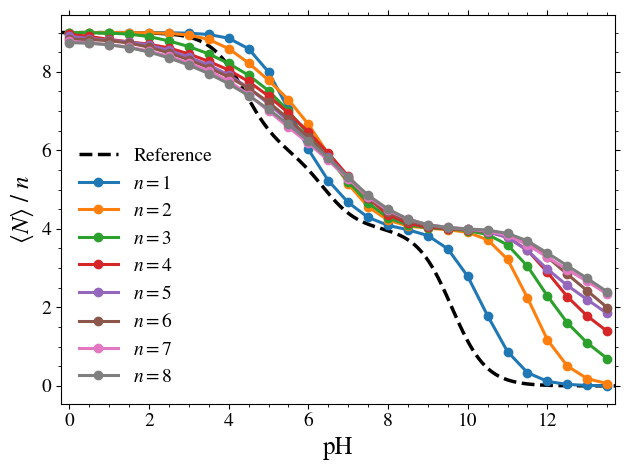

In [8]:
pKas_ref_1mer = (
    [6.4]*2 +   # His
    [4.4]*3 +   # Glu
    [9.6]*4     # Tyr
)

N_ref_1mer = compute_N_avg_reference(np.arange(-1,14,0.01), pKas_ref_1mer)

fig, ax = plt.subplots(nrows=1, ncols=1)

# Plot reference
ax.plot(np.arange(-1,14,0.01), N_ref_1mer/1, linewidth=2.5, label="Reference", color='black', linestyle='dashed')


ax.plot(pHs, N_1mer/1, linewidth=2.2, label=r"$n=1$", marker='o')
ax.plot(pHs, N_2mer/2, linewidth=2.2, label=r"$n=2$", marker='o')
ax.plot(pHs, N_3mer/3, linewidth=2.2, label=r"$n=3$", marker='o')
ax.plot(pHs, N_4mer/4, linewidth=2.2, label=r"$n=4$", marker='o')
ax.plot(pHs, N_5mer/5, linewidth=2.2, label=r"$n=5$", marker='o')
ax.plot(pHs, N_6mer/6, linewidth=2.2, label=r"$n=6$", marker='o')
ax.plot(pHs, N_7mer/7, linewidth=2.2, label=r"$n=7$", marker='o')
ax.plot(pHs, N_8mer/8, linewidth=2.2, label=r"$n=8$", marker='o')

ax.set_xlim(-0.2,13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\langle N \rangle \  / \  n$', fontsize=18)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='best', frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Titration_profiles_all.pdf', bbox_inches='tight')


In [9]:
# --- Error analysis: <N>/n   (manuscript Fig 1 and SI Fig S1) ---
ci95 = {n: np.array([block_ci_mean(data_by_n[n][pH]["N"]) for pH in pHs]) / n for n in data_by_n}
v, nn, ph = largest(ci95, pHs)
print(f"<N>/n  largest 95% CI = +/-{v:.4f} protons/monomer   (n={nn}, pH {ph:.1f})")

<N>/n  largest 95% CI = +/-0.0552 protons/monomer   (n=2, pH 11.5)


In [10]:
# =====================================================================================
# Isoelectric point, and the identity  Delta_nu = charge regulation
# =====================================================================================
# For each titratable site i, with n_i in {0,1}:
#     acids (GL4/AS4, TYR, CYS) : q_i = n_i - 1     (neutral when protonated)
#     bases (HIS/HIP, LYS)      : q_i = n_i         (neutral when deprotonated)
# Summing over all sites of an n-mer gives Q_titratable = N - n*N_acid; adding the
# pH-independent charges (Arg; termini are ACE/NME-capped, so contribute nothing):
#
#     <Q>_n / n = <N>_n / n - N_acid + q_fixed
#
# N_acid and q_fixed are identical for every chain in the series, hence
#
#     Delta_nu_n = <N>_n/n - <N>_1 = <Q>_n/n - <Q>_1        (exactly)
#
# The differential protonation response IS the charge regulation per insulin monomer
# upon self-association.  Since d(ddUpsilon_n)/d(pH) ~ Delta_nu_n, the free-energy
# minimum lies where the CHARGE REGULATION vanishes -- distinct from electroneutrality
# (<Q> = 0), which defines the pI.

ACIDIC_TITRATABLE = {"GL4", "AS4", "GLU", "ASP", "TYR", "CYS"}   # neutral when protonated
BASIC_TITRATABLE  = {"HIS", "HIP", "LYS"}                        # neutral when deprotonated
FIXED_CHARGE      = {"ARG": +1, "LYS": +1, "HIP": +1, "ASP": -1, "GLU": -1, "GL4": -1, "AS4": -1}

comp   = Counter(resnames_1mer)
N_acid = sum(c for r, c in comp.items() if r in ACIDIC_TITRATABLE)
N_base = sum(c for r, c in comp.items() if r in BASIC_TITRATABLE)
assert N_acid + N_base == len(resnames_1mer), f"unclassified titratable site in {dict(comp)}"

titr_idx  = {r["top_index"] for r in titratable_residues}
fixed_res = [r for r in residue_table if (not r["is_cap"])
             and (r["top_index"] not in titr_idx) and (r["resname"] in FIXED_CHARGE)]
q_fixed   = sum(FIXED_CHARGE[r["resname"]] for r in fixed_res)

N_iso  = N_acid - q_fixed                              # <N>/n at the isoelectric point
Q_by_n = {n: N_by_n[n] / n - N_iso for n in N_by_n}    # per-monomer average charge

print(f"Titratable sites / monomer : {dict(comp)}  ->  N_acid = {N_acid}, N_base = {N_base}")
print(f"Fixed charges / monomer    : "
      f"{[(r['bio_chain'] + ':' + str(r['resSeq']), r['resname']) for r in fixed_res]}"
      f"  ->  q_fixed = {q_fixed:+d}")
print(f"  =>  <Q>/n = <N>/n - {N_acid} + ({q_fixed:+d}) = <N>/n - {N_iso}")
print(f"  =>  isoelectric condition: <N>/n = {N_iso}")
_dev = max(np.abs((N_by_n[n]/n - N_by_n[1]) - (Q_by_n[n] - Q_by_n[1])).max() for n in range(2, 9))
print(f"  =>  identity check: max|Delta_nu - Delta_Q| = {_dev:.1e}  (exact by construction)\n")

# ---------------------------------------------------------------------------
# Block-resampled landmarks (20 blocks, Student-t 95% CI -- as elsewhere)
# ---------------------------------------------------------------------------
NB   = 20
Nblk = {n: np.array([[b.mean() for b in np.array_split(np.asarray(data_by_n[n][pH]["N"], float), NB)]
                     for pH in pHs]) for n in data_by_n}          # Nblk[n] : (n_pH, NB)

def _root(y, lo, hi):
    r = interp_sign_change(pHs, y, lo, hi)
    return r[0] if len(r) == 1 else np.nan

def _ci(vals):
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if len(v) < 2:
        return np.nan, np.nan
    return v.mean(), stats.t.ppf(0.975, len(v) - 1) * v.std(ddof=1) / np.sqrt(len(v))

print(f"{'n':>2} | {'pI':^16} | {'pH(dnu=0) = pH(min ddY)':^24} | {'<Q>/n there':^14}")
print("-" * 68)

pI_tab, cross_tab, Qmin_tab = {}, {}, {}
for n in range(1, 9):
    pI_tab[n] = _ci([_root(Nblk[n][:, k] / n - N_iso, pHs.min(), pHs.max()) for k in range(NB)])
    if n == 1:
        print(f"{n:>2} | {pI_tab[n][0]:6.2f} +/- {pI_tab[n][1]:4.2f}   |{'--':^24}|{'--':^14}")
        continue
    # paired blocks: a valid resampling of the *difference* between two independent runs
    cross_tab[n] = _ci([_root(Nblk[n][:, k] / n - Nblk[1][:, k], 3.0, 9.0) for k in range(NB)])
    Qmin_tab[n]  = _ci([np.interp(_root(Nblk[n][:, k] / n - Nblk[1][:, k], 3.0, 9.0),
                                  pHs, Nblk[n][:, k] / n - N_iso) for k in range(NB)])
    print(f"{n:>2} | {pI_tab[n][0]:6.2f} +/- {pI_tab[n][1]:4.2f}   |"
          f"      {cross_tab[n][0]:5.2f} +/- {cross_tab[n][1]:4.2f}       |"
          f"  {Qmin_tab[n][0]:+5.2f} +/- {Qmin_tab[n][1]:4.2f}")

print("\n---------------------------")
print(f"pI, n=1 fibril-conformation monomer  : {pI_tab[1][0]:.2f} +/- {pI_tab[1][1]:.2f}")
print(f"pI, fibrils (n=2-8)                  : "
      f"{min(pI_tab[n][0] for n in range(2,9)):.2f} - {max(pI_tab[n][0] for n in range(2,9)):.2f}")
print(f"free-energy minimum (= dnu crossover): "
      f"{min(cross_tab[n][0] for n in range(2,9)):.2f} - {max(cross_tab[n][0] for n in range(2,9)):.2f}")
print(f"net charge per monomer AT the minimum: "
      f"{np.mean([Qmin_tab[n][0] for n in range(2,9)]):+.2f} e")
print("\nNOTE: this pI is that of the truncated, ACE/NME-capped fibril construct")
print("      (no free chain termini, no Glu A:4, no Lys B:29) and is therefore NOT")
print("      directly comparable to the experimental pI of native insulin (5.3-5.4).")

Titratable sites / monomer : {'TYR': 4, 'GL4': 3, 'HIS': 2}  ->  N_acid = 7, N_base = 2
Fixed charges / monomer    : [('B:37', 'ARG')]  ->  q_fixed = +1
  =>  <Q>/n = <N>/n - 7 + (+1) = <N>/n - 6
  =>  isoelectric condition: <N>/n = 6
  =>  identity check: max|Delta_nu - Delta_Q| = 8.9e-16  (exact by construction)

 n |        pI        | pH(dnu=0) = pH(min ddY)  |  <Q>/n there  
--------------------------------------------------------------------
 1 |   6.01 +/- 0.01   |           --           |      --      
 2 |   6.44 +/- 0.01   |       5.23 +/- 0.01       |  +1.56 +/- 0.02
 3 |   6.34 +/- 0.01   |       5.56 +/- 0.02       |  +0.93 +/- 0.04
 4 |   6.44 +/- 0.02   |       5.59 +/- 0.02       |  +0.87 +/- 0.03
 5 |   6.31 +/- 0.01   |       5.76 +/- 0.01       |  +0.52 +/- 0.02
 6 |   6.31 +/- 0.02   |       5.72 +/- 0.02       |  +0.59 +/- 0.03
 7 |   6.21 +/- 0.02   |       5.87 +/- 0.02       |  +0.29 +/- 0.03
 8 |   6.27 +/- 0.01   |       5.82 +/- 0.02       |  +0.39 +/- 0.02



### Figure 2: Var(N) vs. pH

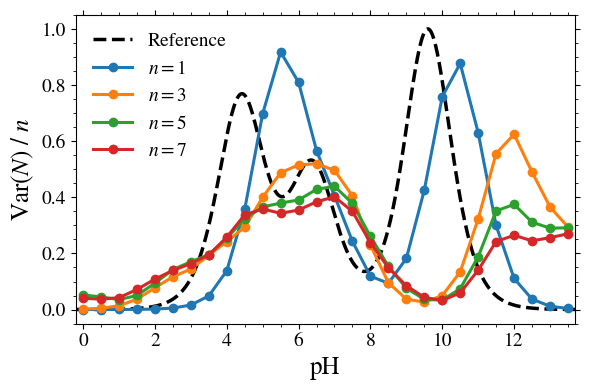

In [12]:
fig, ax = plt.subplots(figsize=(6,4))

pH_ref = np.arange(-1, 14, 0.01)

# Reference
var_ref_1mer = compute_var_reference(pH_ref, pKas_ref_1mer)

ax.plot(pH_ref, var_ref_1mer, linestyle='--', color='black', linewidth=2.5, label="Reference")


ax.plot(pHs, var_1mer/1, marker='o', linewidth=2.2, label=r'$n=1$')
ax.plot(pHs, var_3mer/3, marker='o', linewidth=2.2, label=r'$n=3$')
ax.plot(pHs, var_5mer/5, marker='o', linewidth=2.2, label=r'$n=5$')
ax.plot(pHs, var_7mer/7, marker='o', linewidth=2.2, label=r'$n=7$')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\mathrm{Var}(N) \ / \ n$', fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=14, loc='upper left')

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Proton_capacitance_profiles_odd.pdf', bbox_inches='tight')


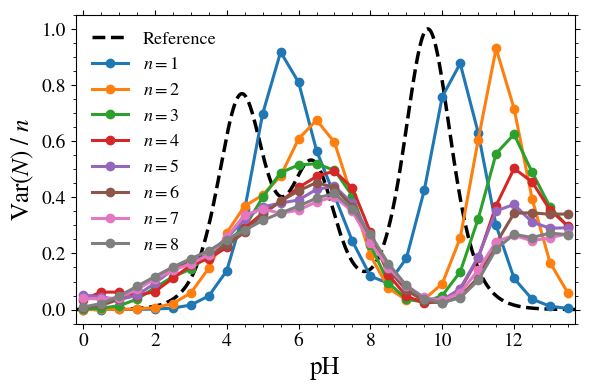

In [13]:
fig, ax = plt.subplots(figsize=(6,4))

pH_ref = np.arange(-1, 14, 0.01)

# Reference
var_ref_1mer = compute_var_reference(pH_ref, pKas_ref_1mer)

ax.plot(pH_ref, var_ref_1mer, linestyle='--', color='black', linewidth=2.5, label="Reference")


ax.plot(pHs, var_1mer/1, marker='o', linewidth=2.2, label=r'$n=1$')
ax.plot(pHs, var_2mer/2, marker='o', linewidth=2.2, label=r'$n=2$')
ax.plot(pHs, var_3mer/3, marker='o', linewidth=2.2, label=r'$n=3$')
ax.plot(pHs, var_4mer/4, marker='o', linewidth=2.2, label=r'$n=4$')
ax.plot(pHs, var_5mer/5, marker='o', linewidth=2.2, label=r'$n=5$')
ax.plot(pHs, var_6mer/6, marker='o', linewidth=2.2, label=r'$n=6$')
ax.plot(pHs, var_7mer/7, marker='o', linewidth=2.2, label=r'$n=7$')
ax.plot(pHs, var_8mer/8, marker='o', linewidth=2.2, label=r'$n=8$')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\mathrm{Var}(N) \ / \ n$', fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=13, loc='upper left')

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Proton_capacitance_profiles_all.pdf', bbox_inches='tight')


In [14]:
# --- Error analysis: Var(N)/n   (SI Fig S2) ---
ci95 = {n: np.array([block_ci_var(data_by_n[n][pH]["N"]) for pH in pHs]) / n for n in data_by_n}
v, nn, ph = largest(ci95, pHs)
print(f"Var(N)/n  largest 95% CI = +/-{v:.4f}   (n={nn}, pH {ph:.1f})")

Var(N)/n  largest 95% CI = +/-0.0246   (n=2, pH 11.0)


### Figure 3: $\Delta \nu_n(\mathrm{pH})$ vs. pH

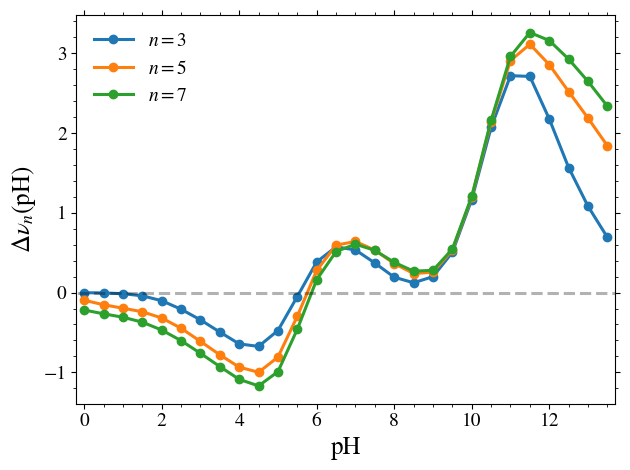

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1)


ax.plot(pHs, N_3mer/3 - N_1mer, linewidth=2.2, label=r"$n=3$", marker='o')
ax.plot(pHs, N_5mer/5 - N_1mer, linewidth=2.2, label=r"$n=5$", marker='o')
ax.plot(pHs, N_7mer/7 - N_1mer, linewidth=2.2, label=r"$n=7$", marker='o')

# Horizontal line for reference
ax.hlines(0, -1, 14, colors='black', alpha=0.3, linestyle='dashed', linewidth=2.2)

ax.set_xlim(-0.2,13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\Delta \nu_n(\mathrm{pH})$', fontsize=18)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='best', frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Differential_protonation_response_odd.pdf', bbox_inches='tight')


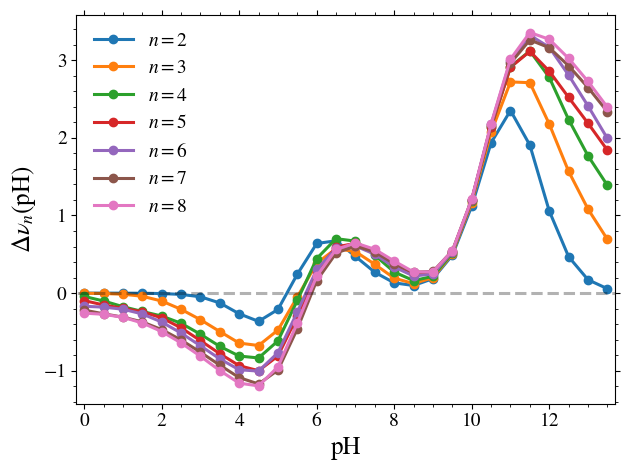

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1)


ax.plot(pHs, N_2mer/2 - N_1mer, linewidth=2.2, label=r"$n=2$", marker='o')
ax.plot(pHs, N_3mer/3 - N_1mer, linewidth=2.2, label=r"$n=3$", marker='o')
ax.plot(pHs, N_4mer/4 - N_1mer, linewidth=2.2, label=r"$n=4$", marker='o')
ax.plot(pHs, N_5mer/5 - N_1mer, linewidth=2.2, label=r"$n=5$", marker='o')
ax.plot(pHs, N_6mer/6 - N_1mer, linewidth=2.2, label=r"$n=6$", marker='o')
ax.plot(pHs, N_7mer/7 - N_1mer, linewidth=2.2, label=r"$n=7$", marker='o')
ax.plot(pHs, N_8mer/8 - N_1mer, linewidth=2.2, label=r"$n=8$", marker='o')

# Horizontal line for reference
ax.hlines(0, -1, 14, colors='black', alpha=0.3, linestyle='dashed', linewidth=2.2)

ax.set_xlim(-0.2,13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r'$\Delta \nu_n(\mathrm{pH})$', fontsize=18)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='best', frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Differential_protonation_response_all.pdf', bbox_inches='tight')


In [17]:
# --- Error analysis: Delta_nu   (manuscript Fig 2 and SI Fig S3) ---
ciN  = {n: np.array([block_ci_mean(data_by_n[n][pH]["N"]) for pH in pHs]) / n for n in data_by_n}
ci95 = {n: np.sqrt(ciN[n] ** 2 + ciN[1] ** 2) for n in range(2, 9)}   # quadrature vs the monomer
v, nn, ph = largest(ci95, pHs)
print(f"Delta_nu  largest 95% CI = +/-{v:.4f} protons/monomer   (n={nn}, pH {ph:.1f})")

Delta_nu  largest 95% CI = +/-0.0552 protons/monomer   (n=2, pH 11.5)


### Figure 4: $\Delta \Upsilon$(pH) vs. pH

In [18]:
# ==========================================================
# 1. Smooth Reference Calculation
# ==========================================================
pH_smooth = np.arange(0, 14, 0.01)
N_avg_ref = compute_N_avg_reference(pH_smooth, pKas_ref_1mer)

# Returns dictionary with {"Upsilon": array} since no variance/M_eff are passed
res_ref = compute_Upsilon_TI_profile(pH_smooth, N_avg_ref, pH_ref=0)
Upsilon_ref = res_ref["Upsilon"]


# ==========================================================
# 2. Compute TI Curves & Uncertainties Simultaneously
# ==========================================================
# We wrap everything in a loop-ready dictionary to avoid repetitive copy-pasting
raw_mer_data = {
    1: (N_1mer, var_1mer, M_1mer),
    2: (N_2mer, var_2mer, M_2mer),
    3: (N_3mer, var_3mer, M_3mer),
    4: (N_4mer, var_4mer, M_4mer),
    5: (N_5mer, var_5mer, M_5mer),
    6: (N_6mer, var_6mer, M_6mer),
    7: (N_7mer, var_7mer, M_7mer),
    8: (N_8mer, var_8mer, M_8mer),
}

# Dictionaries to store your final profiles and total errors
Upsilon_profiles = {}
err_TI_stat = {}
err_TI_disc = {}

for n, (N_avg, var_N, M_eff) in raw_mer_data.items():
        
    # Call the new unified profile function with error parameters included
    res = compute_Upsilon_TI_profile(
        pHs=pHs, 
        N_avg=N_avg, 
        var_N=var_N, 
        M_eff=M_eff, 
        pH_ref=0,
        include_discretization=True
    )
    
    # Extract the results from the returned dictionary
    Upsilon_profiles[n] = res["Upsilon"]
    err_TI_stat[n]      = res["sigma_stat"]
    err_TI_disc[n]      = res["sigma_disc"]

# ==========================================================
# 3. Unpack to Match Your Downstream Script Variables
# ==========================================================
# err_TI[n] = 95% CI of profile Upsilon_n = 1.96*sigma_stat + sigma_disc
err_TI = {n: Z95 * err_TI_stat[n] + err_TI_disc[n] for n in Upsilon_profiles}

Upsilon_1mer, err_TI_1 = Upsilon_profiles[1], err_TI[1]
Upsilon_2mer, err_TI_2 = Upsilon_profiles[2], err_TI[2]
Upsilon_3mer, err_TI_3 = Upsilon_profiles[3], err_TI[3]
Upsilon_4mer, err_TI_4 = Upsilon_profiles[4], err_TI[4]
Upsilon_5mer, err_TI_5 = Upsilon_profiles[5], err_TI[5]
Upsilon_6mer, err_TI_6 = Upsilon_profiles[6], err_TI[6]
Upsilon_7mer, err_TI_7 = Upsilon_profiles[7], err_TI[7]
Upsilon_8mer, err_TI_8 = Upsilon_profiles[8], err_TI[8]


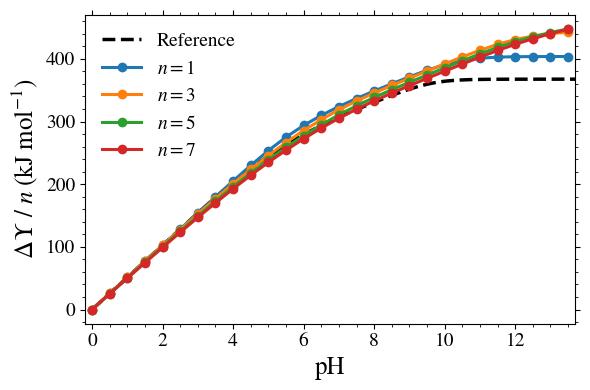

In [19]:
# Plot
fig, ax = plt.subplots(figsize=(6,4))

# Reference
ax.plot(pH_smooth, Upsilon_ref, linestyle='--', color='black', linewidth=2.5, label="Reference")

# Plots with errorbars
#ax.errorbar(pHs, Upsilon_1mer/1, yerr=err_TI_1/1, marker='o', linewidth=2.2, capsize=3, label=r'$n=1$')
#ax.errorbar(pHs, Upsilon_3mer/3, yerr=err_TI_3/3, marker='o', linewidth=2.2, capsize=3, label=r'$n=3$')
#ax.errorbar(pHs, Upsilon_5mer/5, yerr=err_TI_5/5, marker='o', linewidth=2.2, capsize=3, label=r'$n=5$')
#ax.errorbar(pHs, Upsilon_7mer/7, yerr=err_TI_7/7, marker='o', linewidth=2.2, capsize=3, label=r'$n=7$')

# Plots without errorbars
ax.plot(pHs, Upsilon_1mer/1, marker='o', linewidth=2.2, label=r'$n=1$')
ax.plot(pHs, Upsilon_3mer/3, marker='o', linewidth=2.2, label=r'$n=3$')
ax.plot(pHs, Upsilon_5mer/5, marker='o', linewidth=2.2, label=r'$n=5$')
ax.plot(pHs, Upsilon_7mer/7, marker='o', linewidth=2.2, label=r'$n=7$')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r"$\Delta \Upsilon \ / \ n \ \mathrm{(kJ\ mol^{-1})}$", fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Free_energies_per_state_odd.pdf', bbox_inches='tight')


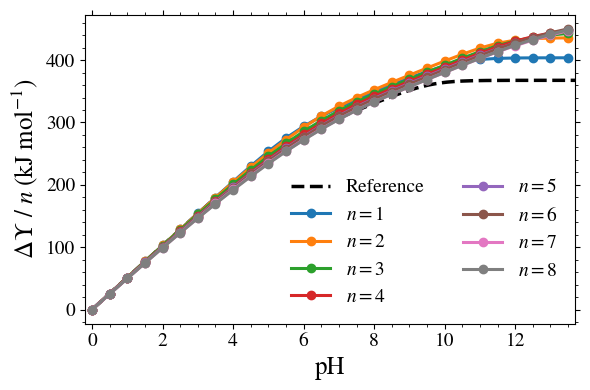

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(6,4))

# Reference
ax.plot(pH_smooth, Upsilon_ref, linestyle='--', color='black', linewidth=2.5, label="Reference")

# Plots with errorbars
#ax.errorbar(pHs, Upsilon_1mer/1, yerr=err_TI_1/1, marker='o', linewidth=2.2, capsize=3, label=r'$n=1$')
#ax.errorbar(pHs, Upsilon_2mer/2, yerr=err_TI_2/2, marker='o', linewidth=2.2, capsize=3, label=r'$n=2$')
#ax.errorbar(pHs, Upsilon_3mer/3, yerr=err_TI_3/3, marker='o', linewidth=2.2, capsize=3, label=r'$n=3$')
#ax.errorbar(pHs, Upsilon_4mer/4, yerr=err_TI_4/4, marker='o', linewidth=2.2, capsize=3, label=r'$n=4$')
#ax.errorbar(pHs, Upsilon_5mer/5, yerr=err_TI_5/5, marker='o', linewidth=2.2, capsize=3, label=r'$n=5$')
#ax.errorbar(pHs, Upsilon_6mer/6, yerr=err_TI_6/6, marker='o', linewidth=2.2, capsize=3, label=r'$n=6$')
#ax.errorbar(pHs, Upsilon_7mer/7, yerr=err_TI_7/7, marker='o', linewidth=2.2, capsize=3, label=r'$n=7$')
#ax.errorbar(pHs, Upsilon_8mer/8, yerr=err_TI_8/8, marker='o', linewidth=2.2, capsize=3, label=r'$n=8$')

# Plots without errorbars
ax.plot(pHs, Upsilon_1mer/1, marker='o', linewidth=2.2, label=r'$n=1$')
ax.plot(pHs, Upsilon_2mer/2, marker='o', linewidth=2.2, label=r'$n=2$')
ax.plot(pHs, Upsilon_3mer/3, marker='o', linewidth=2.2, label=r'$n=3$')
ax.plot(pHs, Upsilon_4mer/4, marker='o', linewidth=2.2, label=r'$n=4$')
ax.plot(pHs, Upsilon_5mer/5, marker='o', linewidth=2.2, label=r'$n=5$')
ax.plot(pHs, Upsilon_6mer/6, marker='o', linewidth=2.2, label=r'$n=6$')
ax.plot(pHs, Upsilon_7mer/7, marker='o', linewidth=2.2, label=r'$n=7$')
ax.plot(pHs, Upsilon_8mer/8, marker='o', linewidth=2.2, label=r'$n=8$')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r"$\Delta \Upsilon \ / \ n \ \mathrm{(kJ\ mol^{-1})}$", fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=14, loc='lower right', ncols=2)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Free_energies_per_state_all.pdf', bbox_inches='tight')


In [21]:
# --- Error analysis: Delta Upsilon / n   (SI Fig S4) ---
# err_TI[n] is the profile 95% CI (1.96*sigma_stat + sigma_disc, linear); per monomer.
ci95 = {n: err_TI[n] / n for n in err_TI}
v, nn, ph = largest(ci95, pHs)
print(f"dUpsilon/n  largest 95% CI = +/-{v:.4f} kJ/mol   (n={nn}, pH {ph:.1f})")

dUpsilon/n  largest 95% CI = +/-0.2964 kJ/mol   (n=1, pH 10.5)


### Figure 5: $\Delta\Delta\Upsilon$(pH) vs. pH - Effect of self-association

In [22]:
# ==========================================================
# 1. Per-monomer Free Energy Differences
# ==========================================================
Delta_Upsilon_2mer_per_monomer = (Upsilon_2mer / 2.0) - Upsilon_1mer
Delta_Upsilon_3mer_per_monomer = (Upsilon_3mer / 3.0) - Upsilon_1mer
Delta_Upsilon_4mer_per_monomer = (Upsilon_4mer / 4.0) - Upsilon_1mer
Delta_Upsilon_5mer_per_monomer = (Upsilon_5mer / 5.0) - Upsilon_1mer
Delta_Upsilon_6mer_per_monomer = (Upsilon_6mer / 6.0) - Upsilon_1mer
Delta_Upsilon_7mer_per_monomer = (Upsilon_7mer / 7.0) - Upsilon_1mer
Delta_Upsilon_8mer_per_monomer = (Upsilon_8mer / 8.0) - Upsilon_1mer

# ==========================================================
# 2. 95% CI for ddUpsilon_n = Upsilon_n/n - Upsilon_1
# ==========================================================
# statistical: two independent simulations -> quadrature
# discretization: systematic -> linear addition of magnitudes
# total 95% CI = 1.96*sigma_stat(dd) + sigma_disc(dd)
def _ddU_ci95(n):
    stat = np.sqrt((err_TI_stat[n] / n)**2 + err_TI_stat[1]**2)
    disc = err_TI_disc[n] / n + err_TI_disc[1]
    return Z95 * stat + disc

err_2 = _ddU_ci95(2)
err_3 = _ddU_ci95(3)
err_4 = _ddU_ci95(4)
err_5 = _ddU_ci95(5)
err_6 = _ddU_ci95(6)
err_7 = _ddU_ci95(7)
err_8 = _ddU_ci95(8)


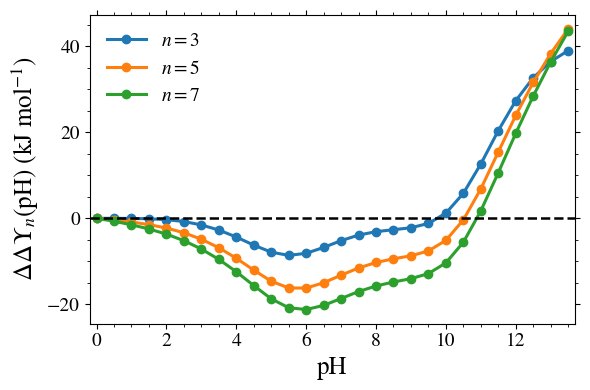

In [23]:
fig, ax = plt.subplots(figsize=(6,4))

# Plots with errorbars
#ax.errorbar(pHs, Delta_Upsilon_3mer_per_monomer, yerr=err_3, linewidth=2.2, marker='o', capsize=3, label=r'$n=3$')
#ax.errorbar(pHs, Delta_Upsilon_5mer_per_monomer, yerr=err_5, linewidth=2.2, marker='o', capsize=3, label=r'$n=5$')
#ax.errorbar(pHs, Delta_Upsilon_7mer_per_monomer, yerr=err_7, linewidth=2.2, marker='o', capsize=3, label=r'$n=7$')

# Plots without errorbars
ax.plot(pHs, Delta_Upsilon_3mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=3$')
ax.plot(pHs, Delta_Upsilon_5mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=5$')
ax.plot(pHs, Delta_Upsilon_7mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=7$')

# Zero line
ax.axhline(0.0, linestyle='--', linewidth=1.8, color='black')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r"$\Delta\Delta\Upsilon_n(\mathrm{pH})$ (kJ mol$^{-1}$)", fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=14)

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Free_energies_ddUpsilon_odd.pdf', bbox_inches='tight')


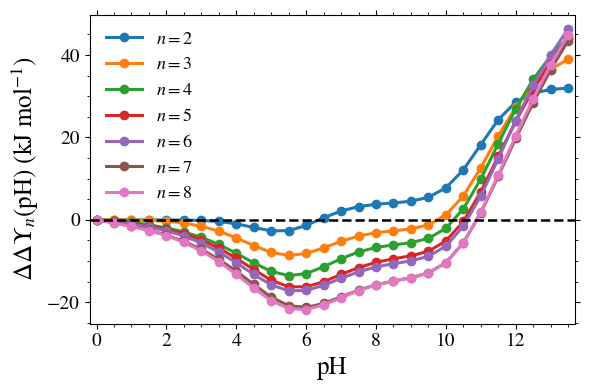

In [24]:
fig, ax = plt.subplots(figsize=(6,4))

# Plots with errorbars
#ax.errorbar(pHs, Delta_Upsilon_2mer_per_monomer, yerr=err_2, linewidth=2.2, marker='o', capsize=3, label=r'$n=2$')
#ax.errorbar(pHs, Delta_Upsilon_3mer_per_monomer, yerr=err_3, linewidth=2.2, marker='o', capsize=3, label=r'$n=3$')
#ax.errorbar(pHs, Delta_Upsilon_4mer_per_monomer, yerr=err_4, linewidth=2.2, marker='o', capsize=3, label=r'$n=4$')
#ax.errorbar(pHs, Delta_Upsilon_5mer_per_monomer, yerr=err_5, linewidth=2.2, marker='o', capsize=3, label=r'$n=5$')
#ax.errorbar(pHs, Delta_Upsilon_6mer_per_monomer, yerr=err_6, linewidth=2.2, marker='o', capsize=3, label=r'$n=6$')
#ax.errorbar(pHs, Delta_Upsilon_7mer_per_monomer, yerr=err_7, linewidth=2.2, marker='o', capsize=3, label=r'$n=7$')
#ax.errorbar(pHs, Delta_Upsilon_8mer_per_monomer, yerr=err_8, linewidth=2.2, marker='o', capsize=3, label=r'$n=8$')

# Plots without errorbars
ax.plot(pHs, Delta_Upsilon_2mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=2$')
ax.plot(pHs, Delta_Upsilon_3mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=3$')
ax.plot(pHs, Delta_Upsilon_4mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=4$')
ax.plot(pHs, Delta_Upsilon_5mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=5$')
ax.plot(pHs, Delta_Upsilon_6mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=6$')
ax.plot(pHs, Delta_Upsilon_7mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=7$')
ax.plot(pHs, Delta_Upsilon_8mer_per_monomer, linewidth=2.2, marker='o', label=r'$n=8$')

# Zero line
ax.axhline(0.0, linestyle='--', linewidth=1.8, color='black')

# Axes
ax.set_xlim(-0.2, 13.7)
ax.set_xlabel("pH", fontsize=18)
ax.set_ylabel(r"$\Delta\Delta\Upsilon_n(\mathrm{pH})$ (kJ mol$^{-1}$)", fontsize=18)

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=13, loc='upper left')

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Free_energies_ddUpsilon_all.pdf', bbox_inches='tight')


In [25]:
# --- Error analysis: Delta Delta Upsilon   (manuscript Fig 3 and SI Fig S5) ---
ddU_by_n = {2: Delta_Upsilon_2mer_per_monomer, 3: Delta_Upsilon_3mer_per_monomer,
            4: Delta_Upsilon_4mer_per_monomer, 5: Delta_Upsilon_5mer_per_monomer,
            6: Delta_Upsilon_6mer_per_monomer, 7: Delta_Upsilon_7mer_per_monomer,
            8: Delta_Upsilon_8mer_per_monomer}
ci95 = {2: err_2, 3: err_3, 4: err_4, 5: err_5, 6: err_6, 7: err_7, 8: err_8}   # 95% CI = 1.96*sigma_stat + sigma_disc
v, nn, ph = largest(ci95, pHs)
print(f"ddUpsilon  largest 95% CI = +/-{v:.4f} kJ/mol   (n={nn}, pH {ph:.1f})")

ddUpsilon  largest 95% CI = +/-0.4305 kJ/mol   (n=2, pH 6.0)


### Figure 6: Free energy landscape $\Delta\Delta\Upsilon(\mathrm{pH},n)$

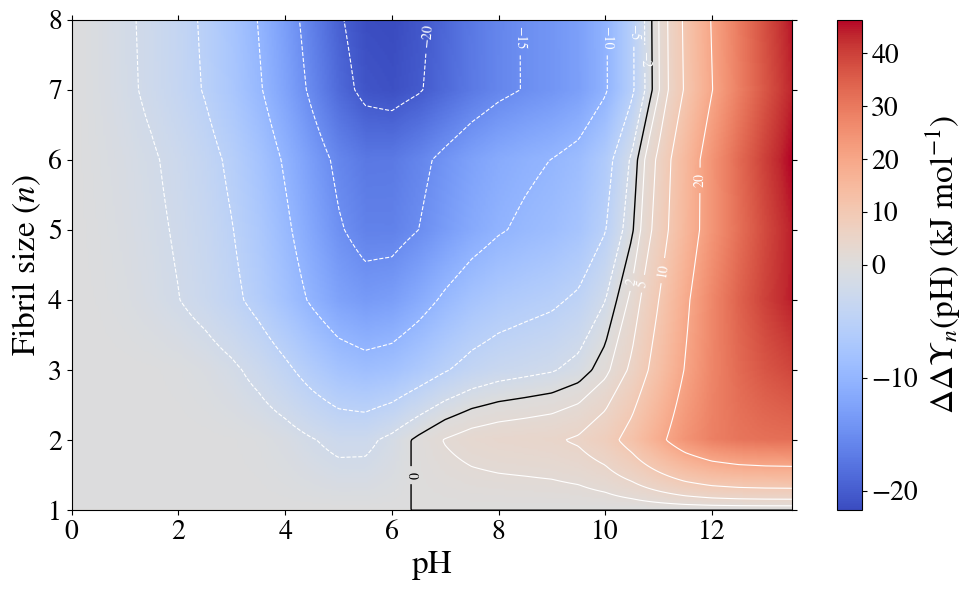

In [26]:
n_values = np.array([1, 2, 3, 4, 5, 6, 7, 8])

heatmap_data = np.vstack([
    np.zeros_like(pHs),  # n = 1 reference
    Delta_Upsilon_2mer_per_monomer,
    Delta_Upsilon_3mer_per_monomer,
    Delta_Upsilon_4mer_per_monomer,
    Delta_Upsilon_5mer_per_monomer,
    Delta_Upsilon_6mer_per_monomer,
    Delta_Upsilon_7mer_per_monomer,
    Delta_Upsilon_8mer_per_monomer
])

# Interpolation
interp = RegularGridInterpolator(
    (n_values, pHs),
    heatmap_data,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)

# Fine grid
pH_fine = np.linspace(pHs.min(), pHs.max(), 300)
n_fine = np.linspace(1, 8, 300)

P, N = np.meshgrid(pH_fine, n_fine)

points = np.array([N.flatten(), P.flatten()]).T
Z_fine = interp(points).reshape(N.shape)

# Color scaling
vmin = np.nanmin(Z_fine)
vmax = np.nanmax(Z_fine)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

im = ax.imshow(
    Z_fine,
    aspect='auto',
    origin='lower',
    extent=[pH_fine.min(), pH_fine.max(), n_fine.min(), n_fine.max()],
    cmap='coolwarm',
    norm=norm
)

# Contours (exclude zero)
levels = [-20, -15, -10, -5, -2, 2, 5, 10, 20]

contours = ax.contour(
    pH_fine,
    n_fine,
    Z_fine,
    levels=levels,
    colors='white',
    linewidths=0.8
)

ax.clabel(contours, inline=True, fontsize=10, colors='white')

# Zero contour (highlighted)
zero_contour = ax.contour(
    pH_fine,
    n_fine,
    Z_fine,
    levels=[0],
    colors='black',
    linewidths=1.0
)

# Manual placement helps readability
ax.clabel(zero_contour, fmt='%d', fontsize=10, manual=[(6.5, 1.5)])

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r"$\Delta\Delta\Upsilon_n(\mathrm{pH})$ (kJ mol$^{-1}$)", fontsize=24)

# Axes formatting
ax.set_xlabel('pH', fontsize=24)
ax.set_ylabel('Fibril size ($n$)', fontsize=24)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_yticks([1,2,3,4,5,6,7,8])
ax.set_xlim(pHs.min(), pHs.max())
ax.set_ylim(1, 8)

# Final layout
fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Heatmap_ddUpsilon_pH_0_norm.pdf', bbox_inches='tight')


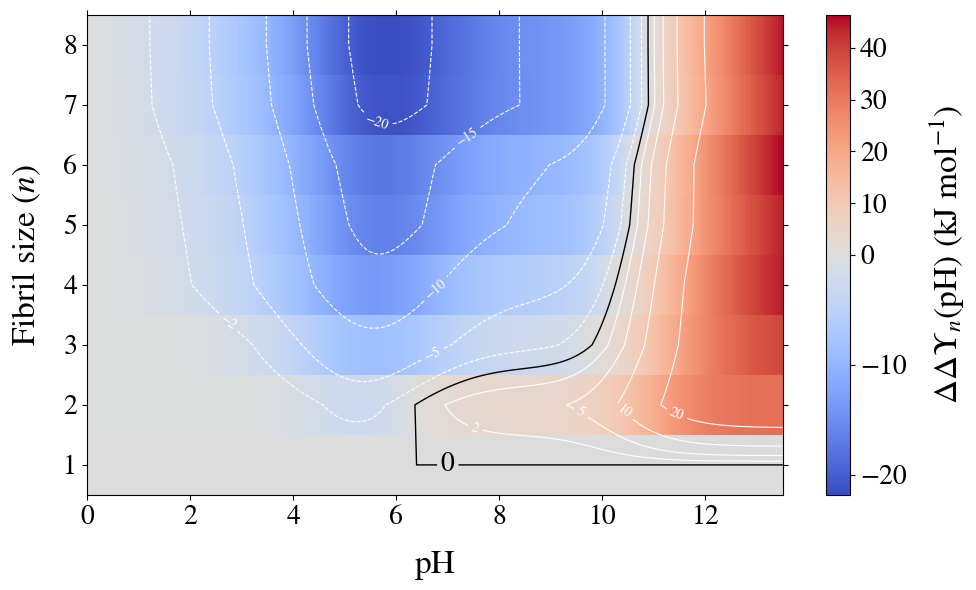

In [27]:
# ============================================
# Data
# ============================================

n_values = np.array([1,2,3,4,5,6,7,8])

heatmap_data = np.vstack([
    np.zeros_like(pHs),
    Delta_Upsilon_2mer_per_monomer,
    Delta_Upsilon_3mer_per_monomer,
    Delta_Upsilon_4mer_per_monomer,
    Delta_Upsilon_5mer_per_monomer,
    Delta_Upsilon_6mer_per_monomer,
    Delta_Upsilon_7mer_per_monomer,
    Delta_Upsilon_8mer_per_monomer
])

# ============================================
# Interpolate ONLY along pH
# ============================================

pH_fine = np.linspace(pHs.min(), pHs.max(), 400)

Z_interp = np.zeros((len(n_values), len(pH_fine)))

for i in range(len(n_values)):
    
    f = interp1d(
        pHs,
        heatmap_data[i],
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )
    
    Z_interp[i] = f(pH_fine)

# ============================================
# Create discrete y-bin edges
# ============================================

y_edges = np.arange(0.5, 8.5 + 1, 1)
x_edges = np.linspace(pH_fine.min(), pH_fine.max(), len(pH_fine)+1)

# ============================================
# Color normalization
# ============================================

vmin = np.nanmin(Z_interp)
vmax = np.nanmax(Z_interp)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)

# ============================================
# Plot
# ============================================

fig, ax = plt.subplots(figsize=(10,6))

mesh = ax.pcolormesh(
    x_edges,
    y_edges,
    Z_interp,
    cmap='coolwarm',
    norm=norm,
    shading='flat',
    rasterized=True
)

# ============================================
# Contours
# ============================================

# Extended contour grid
n_contour = np.append(n_values, 9)

Z_contour = np.vstack([
    Z_interp,
    Z_interp[-1]   # duplicate n=8 row
])

P, N = np.meshgrid(pH_fine, n_contour)

levels = [-20, -15, -10, -5, -2, 2, 5, 10, 20]

contours = ax.contour(
    P,
    N,
    Z_contour,
    levels=levels,
    colors='white',
    linewidths=0.8
)

manual_positions = [
    # Negative contours + zero-like region
    (5.616541353383457, 6.7149587319294195),  # -20
    (7.375939849624055, 6.455064594948061),   # -15
    (6.766917293233082, 3.9239887255371007),  # -10
    (6.69924812030075, 2.8444445809723176),   # -5
    (2.740601503759398, 3.378543948174738),   # -2

    # Manually adjusted positive contours
    (7.5, 1.5),    # 2
    (9.5, 1.7),    # 5
    (10.5, 2.0),   # 10
    (11.5, 2.0),   # 20
]

clabels = ax.clabel(
    contours,
    inline=True,
    fontsize=10,
    colors='white',
    manual=manual_positions
)

# Zero contour
zero_contour = ax.contour(
    P,
    N,
    Z_contour,
    levels=[0],
    colors='black',
    linewidths=1.0
)

ax.clabel(
    zero_contour,
    fmt='%d',
    fontsize=20,
    manual=[(7, 1.5)]
)

# ============================================
# Colorbar
# ============================================

cbar = plt.colorbar(mesh, ax=ax)

cbar.ax.tick_params(labelsize=20)

cbar.set_label(r"$\Delta\Delta\Upsilon_n(\mathrm{pH})$ (kJ mol$^{-1}$)",fontsize=24, labelpad=15)

# ============================================
# Axes
# ============================================

ax.set_xlabel('pH', fontsize=24, labelpad=15)

ax.set_ylabel(r'Fibril size ($n$)', fontsize=24, labelpad=15)

ax.set_yticks(n_values)

ax.set_xlim(pHs.min(), pHs.max())

ax.set_ylim(0.5, 8.5)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=20
)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

# ============================================
# Final layout
# ============================================

fig.tight_layout()

fig.savefig(
    'Figures/Thermodynamics_Figures/Heatmap_ddUpsilon_pH_0_norm_discrete.pdf',
    bbox_inches='tight'
)


## Figure 7: Size Dependence of $\Delta\Delta\Upsilon(n)$

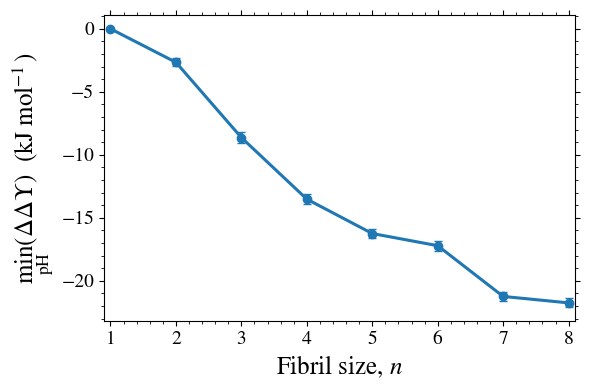

In [31]:
fig, ax = plt.subplots(figsize=(6,4))

# n=1 is the reference: ddUpsilon == 0 identically, so no error
ddU_list = {2: Delta_Upsilon_2mer_per_monomer, 3: Delta_Upsilon_3mer_per_monomer,
            4: Delta_Upsilon_4mer_per_monomer, 5: Delta_Upsilon_5mer_per_monomer,
            6: Delta_Upsilon_6mer_per_monomer, 7: Delta_Upsilon_7mer_per_monomer,
            8: Delta_Upsilon_8mer_per_monomer}
err_list = {2: err_2, 3: err_3, 4: err_4, 5: err_5, 6: err_6, 7: err_7, 8: err_8}

x_data = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y_data = [0.0]        # n=1
y_err  = [0.0]        # n=1 (exact zero)

for n in range(2, 9):
    i = int(np.argmin(ddU_list[n]))     # index of the pH minimum
    y_data.append(ddU_list[n][i])
    y_err.append(err_list[n][i])        # 95% CI at that same pH

y_data = np.array(y_data)
y_err  = np.array(y_err)

ax.errorbar(x_data, y_data, yerr=y_err, marker='o', linewidth=2.2, capsize=3)

ax.set_xlim(0.9, 8.1)
ax.set_xlabel(r"Fibril size, $n$", fontsize=18)
ax.set_ylabel(r"$\min_\mathrm{pH}\left(\Delta\Delta\Upsilon\right)$  (kJ mol$^{-1}$)", fontsize=18)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

fig.tight_layout()
fig.savefig('Figures/Thermodynamics_Figures/Minimum_free_energy_oligomerzation.pdf', bbox_inches='tight')

## TOC Figure

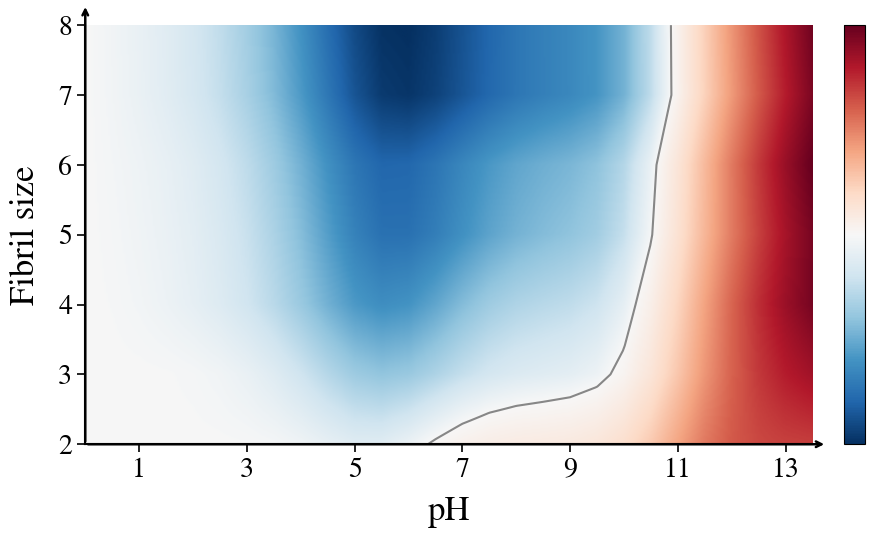

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import TwoSlopeNorm

# ============================================================
# Data
# ============================================================

n_values = np.array([1, 2, 3, 4, 5, 6, 7, 8])

heatmap_data = np.vstack([
    np.zeros_like(pHs),  # n = 1 reference
    Delta_Upsilon_2mer_per_monomer,
    Delta_Upsilon_3mer_per_monomer,
    Delta_Upsilon_4mer_per_monomer,
    Delta_Upsilon_5mer_per_monomer,
    Delta_Upsilon_6mer_per_monomer,
    Delta_Upsilon_7mer_per_monomer,
    Delta_Upsilon_8mer_per_monomer
])

# ============================================================
# Interpolation
# ============================================================

interp = RegularGridInterpolator(
    (n_values, pHs),
    heatmap_data,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)

# Fine grid
pH_fine = np.linspace(pHs.min(), pHs.max(), 400)
n_fine = np.linspace(1, 8, 400)

P, N = np.meshgrid(pH_fine, n_fine)

points = np.array([N.flatten(), P.flatten()]).T
Z_fine = interp(points).reshape(N.shape)

# ============================================================
# Color normalization
# ============================================================

vmin = np.nanmin(Z_fine)
vmax = np.nanmax(Z_fine)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(9,5.5))

# ------------------------------------------------------------
# Smooth thermodynamic landscape
# ------------------------------------------------------------

im = ax.imshow(
    Z_fine,
    aspect='auto',
    origin='lower',
    extent=[
        pH_fine.min(),
        pH_fine.max(),
        n_fine.min(),
        n_fine.max()
    ],
    cmap='RdBu_r',
    norm=norm,
    interpolation='bicubic'
)

# ------------------------------------------------------------
# Subtle zero contour
# ------------------------------------------------------------

ax.contour(
    pH_fine,
    n_fine,
    Z_fine,
    levels=[0],
    colors='black',
    linewidths=1.5,
    alpha=0.45
)

# ------------------------------------------------------------
# Minimal conceptual annotations
# ------------------------------------------------------------

#ax.text(
#    7.4, 6.6,
#    'Electrostatic\nrepulsion',
#    color='white',
#    fontsize=15,
#    ha='center',
#    va='center',
#    weight='bold'
#)
#
#ax.text(
#    4.8, 6.1,
#    'Proton-mediated\nstabilization?',
#    color='black',
#    fontsize=15,
#    ha='center',
#    va='center',
#    weight='bold'
#)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlim(pHs.min(), pHs.max())
ax.set_ylim(2, 8)

# Sparse ticks only
ax.set_xticks([1, 3, 5, 7, 9, 11, 13])
ax.set_yticks([2, 3, 4, 5, 6, 7, 8])

ax.tick_params(
    axis='both',
    which='major',
    labelsize=20,
    length=6,
    width=1.2
)

# Labels
ax.set_xlabel(
    'pH',
    fontsize=25,
    labelpad=10
)

ax.set_ylabel(
    'Fibril size',
    fontsize=25,
    labelpad=12
)

# ------------------------------------------------------------
# Clean spines
# ------------------------------------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# ------------------------------------------------------------
# Arrow axes
# ------------------------------------------------------------

# x-axis arrow
ax.annotate(
    '',
    xy=(1.02, 0),
    xycoords=('axes fraction', 'axes fraction'),
    xytext=(0, 0),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.8,
        color='black'
    )
)

# y-axis arrow
ax.annotate(
    '',
    xy=(0, 1.05),
    xycoords=('axes fraction', 'axes fraction'),
    xytext=(0, 0),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.8,
        color='black'
    )
)

# ------------------------------------------------------------
# Compact colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.045,
    pad=0.04
)

cbar.set_ticks([])

#cbar.ax.text(
#    2.6, 0.88,
#    'Fibril\nfavored',
#    transform=cbar.ax.transAxes,
#    fontsize=12,
#    ha='left',
#    va='center'
#)
#
#cbar.ax.text(
#    2.6, 0.12,
#    'Fibril\ndisfavored',
#    transform=cbar.ax.transAxes,
#    fontsize=12,
#    ha='left',
#    va='center'
#)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

fig.tight_layout()

# ============================================================
# Save
# ============================================================

fig.savefig(
    'Figures/Thermodynamics_Figures/TOC_landscape_clean.pdf',
    bbox_inches='tight',
    transparent=True,
    dpi=300
)

plt.show()